# Plotting Code for EXP2: Hidden State Ablation Study

In [54]:
import numpy as np
import pickle as pkl
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
os.chdir(r"""C:\Users\thgla\Documents\GitHub\ADALaS""")

In [55]:
FILENAMES = {
    "full_prop": r"data\test_results\alpaca\full_prop-1.3b_alpaca_27-08_18-16-38",
    "eval_full_prop": r"data\test_results\alpaca\eval_full_prop-1.3b_alpaca_28-08_14-17-42",
    "hidden_state": {
        2: r"data\test_results\alpaca\HS_2-1.3b_alpaca_27-08_18-52-12",
        4: r"data\test_results\alpaca\HS_4-1.3b_alpaca_27-08_19-29-02",
        6: r"data\test_results\alpaca\HS_6-1.3b_alpaca_27-08_20-06-02",
        10: r"data\test_results\alpaca\HS_10-1.3b_alpaca_27-08_20-43-17",
    },
    "fixed": {
        2: r"data\test_results\alpaca\fixed_2-1.3b_alpaca_27-08_21-20-06",
        4: r"data\test_results\alpaca\fixed_4-1.3b_alpaca_27-08_21-58-56",
        6: r"data\test_results\alpaca\fixed_6-1.3b_alpaca_27-08_22-36-18",
        10: r"data\test_results\alpaca\fixed_10-1.3b_alpaca_27-08_23-13-20",
    },
    "ULS": {
        12: r"data\test_results\alpaca\ULS_12L-1.3b_alpaca_28-08_02-12-08",
        8: r"data\test_results\alpaca\ULS_8L-1.3b_alpaca_28-08_02-48-04",
        6: r"data\test_results\alpaca\ULS_6L-1.3b_alpaca_28-08_03-24-02",
        4: r"data\test_results\alpaca\ULS_4L-1.3b_alpaca_28-08_04-01-03",
    },
    "eval_hidden_state": {
        2: r"data\test_results\alpaca\eval_HS_2-1.3b_alpaca_28-08_14-53-11",
        4: r"data\test_results\alpaca\eval_HS_4-1.3b_alpaca_28-08_15-30-22",
        6: r"data\test_results\alpaca\eval_HS_6-1.3b_alpaca_28-08_16-07-28",
        10: r"data\test_results\alpaca\eval_HS_10-1.3b_alpaca_28-08_16-44-36",
    },
}
shards = 5
alphas = [2,4,6,10]
data_dict = {}
data_dict["full_prop"] = [pkl.load(open(FILENAMES["full_prop"]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["eval_full_prop"] = [pkl.load(open(FILENAMES["eval_full_prop"]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["hidden_state"] = {}
for alpha in FILENAMES["hidden_state"]:
    data_dict["hidden_state"][alpha] = [pkl.load(open(FILENAMES["hidden_state"][alpha]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["fixed"] = {}
for alpha in FILENAMES["fixed"]:
    data_dict["fixed"][alpha] = [pkl.load(open(FILENAMES["fixed"][alpha]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["ULS"] = {}
for k in FILENAMES["ULS"]:
    data_dict["ULS"][k] = [pkl.load(open(FILENAMES["ULS"][k] + f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["eval_hidden_state"] = {}
for alpha in FILENAMES["eval_hidden_state"]:
    data_dict["eval_hidden_state"][alpha] = [pkl.load(open(FILENAMES["eval_hidden_state"][alpha]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]


In [56]:
print(data_dict["eval_hidden_state"][4][0]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][1]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][2]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][3]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][4]["rouge_L_avg"])
print("mean")
print(np.mean([data_dict["eval_hidden_state"][4][i]["rouge_L_avg"] for i in range(shards)]))


0.3152732785286581
0.32534680018805995
0.32032462874736006
0.3185236894184396
0.3221758212906568
mean
0.3203288436346349


In [63]:
print(data_dict["full_prop"][0].keys())
print(data_dict["hidden_state"][alpha][i]["layer_skip_percentages"])

dict_keys(['predictions', 'labels', 'inputs', 'rouge_1_avg', 'rouge_2_avg', 'rouge_L_avg', 'rouge_1_ind', 'rouge_2_ind', 'rouge_L_ind', 'layer_skip_percentages'])
[0.0, 0.8913642061904904, 0.8252992269349013, 0.8894875085813211, 0.9398897113691311, 0.9550749186640003, 0.9779609288720413, 0.8699407515744859, 0.9389047249500044, 0.8862042205175656, 0.7920745903351939, 0.8023199414977763, 0.8549159776736411, 0.8211503447452467, 0.7771132435901262, 0.6952735575918575, 0.39642345461600453, 0.47953168372981525, 0.3858721607020267, 0.3700004477210996, 0.5633488045846641, 0.6437893621466735, 0.9533885025221622, 0.0]


In [170]:
HS_perc_skip = [[data_dict["hidden_state"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]
perc_skip_HS = [np.mean(HS_perc_skip[i]) for i in range(len(alphas))]
perc_layer_use_HS = [(1 - perc_skip_HS[i])*24.0 for i in range(len(alphas))]

fixed_perc_skip = [[data_dict["fixed"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]
perc_skip_fixed = [np.mean(fixed_perc_skip[i]) for i in range(len(alphas))]
perc_layer_use_fixed = [(1 - perc_skip_fixed[i])*24.0 for i in range(len(alphas))]

#create a dataframe
df = pd.DataFrame(columns=["rougeL", "layer_use_perc", "strategy", "alpha"])
for alpha in FILENAMES["hidden_state"]:
    for i in range(shards):
        df_temp = pd.DataFrame(data_dict["hidden_state"][alpha][i]["rouge_L_ind"],columns=["rougeL"])
        df_temp["layer_use_perc"] =  perc_layer_use_HS[alphas.index(alpha)]
        df_temp["strategy"] = "Hidden state"
        df_temp["alpha"] = alpha
        df = pd.concat([df,df_temp],ignore_index=True,axis=0)
for alpha in FILENAMES["fixed"]:
    for i in range(shards):
        df_temp = pd.DataFrame(data_dict["fixed"][alpha][i]["rouge_L_ind"],columns=["rougeL"])
        df_temp["layer_use_perc"] =  perc_layer_use_fixed[alphas.index(alpha)]
        df_temp["strategy"] = "Fixed Input"
        df_temp["alpha"] = alpha
        df = pd.concat([df,df_temp],ignore_index=True,axis=0)

full_model_df = pd.DataFrame(columns=["rougeL", "layer_use_perc", "strategy"])
for i in range(shards):
    df_temp = pd.DataFrame(data_dict["full_prop"][i]["rouge_L_ind"],columns=["rougeL"])
    df_temp["layer_use_perc"] = 24.0
    df_temp["strategy"] = "Full model"
    full_model_df = pd.concat([full_model_df,df_temp],ignore_index=True,axis=0)
    df_temp["layer_use_perc"] = 0.0
    full_model_df = pd.concat([full_model_df,df_temp],ignore_index=True,axis=0)
        

C:\Users\thgla\AppData\Local\Temp\ipykernel_15212\3885743470.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_temp],ignore_index=True,axis=0)
C:\Users\thgla\AppData\Local\Temp\ipykernel_15212\3885743470.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_model_df = pd.concat([full_model_df,df_temp],ignore_index=True,axis=0)


In [157]:
print(full_model_df)

         rougeL  layer_use_perc    strategy
0      0.259386            24.0  Full model
1      0.377953            24.0  Full model
2      0.800000            24.0  Full model
3      0.216561            24.0  Full model
4      0.750000            24.0  Full model
...         ...             ...         ...
15597  0.320988             0.0  Full model
15598  0.615385             0.0  Full model
15599  0.034965             0.0  Full model
15600  0.120482             0.0  Full model
15601  0.000000             0.0  Full model

[15602 rows x 3 columns]


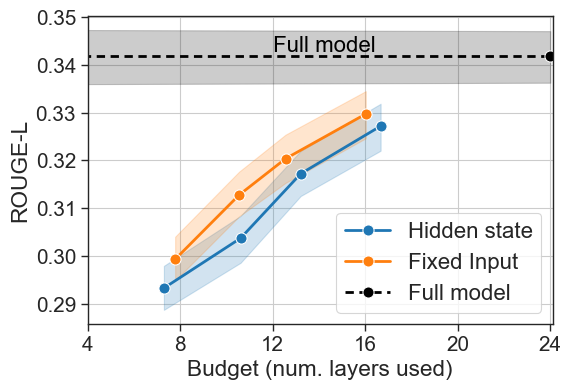

In [195]:
#plot
sns.set_theme(context="paper", style="ticks", font_scale=1.7,palette="tab10")
plt.figure(figsize=(6,4), facecolor='#FFF')
sns.lineplot(x="layer_use_perc", y="rougeL", hue="strategy", data=df, errorbar=("ci",95), err_style="band", markers=("o", "o"), style="strategy", dashes=("",""),markersize=8,linewidth=2)  
#add horizontal line for full model, with confidence interval as band
sns.lineplot(x="layer_use_perc", y="rougeL", hue="strategy", data=full_model_df, palette=['black'], err_style="band", errorbar=("ci",95), markers="o", style="strategy", dashes=((3,2),),markersize=8,linewidth=2)
plt.text(12, np.mean(full_model_df["rougeL"])+0.001, "Full model", fontsize=16, color="black")
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend(fontsize=16)
plt.xlim(4,24.1)
plt.xticks(np.arange(4,25,4))
plt.grid()
plt.savefig(r"data\eval_results\alpaca\layer_use_rouge.pdf", bbox_inches='tight')
plt.show()


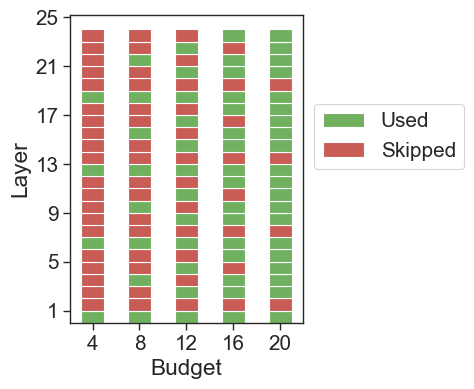

In [225]:
#plot the layer skipping distribution
def ULS(b,L):
    layer_skips = np.array([])
    for l in range(L):
        skip = 1 if np.sum(layer_skips) <= l*b/L else 0
        layer_skips = np.append(layer_skips,skip)
    return layer_skips

#plot the layer skipping distribution for b= 4,8,12,24
sns.set_theme(context="paper", style="ticks", font_scale=1.7,palette="tab10")
plt.figure(figsize=(3,4), facecolor='#FFF')
# stacked bar plot, green is used, red is skipped
for i in [4,8,12,16,20]:
    skips = ULS(i,24)
    for j in range(24):
        plt.bar(str(i),1,bottom=j,color= (113/255.0,176/255.0,95/255.0,255/255.0) if skips[j] == 1 else (202/255.0,92/255.0,86/255.0,255/255.0),width=0.5)
plt.ylabel("Layer")
plt.xlabel("Budget")
plt.legend(["Used","Skipped"],loc=(1.05,0.5))
plt.yticks(np.arange(1,26,4))
plt.savefig(r"data\eval_results\alpaca\layer_use_dist.pdf", bbox_inches='tight')
plt.show()

# OLD CODE

In [50]:
full_prop_rougeL = [data_dict["full_prop"][i]["rouge_L_avg"] for i in range(shards)]
full_prop_perc_skip = [data_dict["full_prop"][i]["layer_skip_percentages"] for i in range(shards)]

eval_full_prop_rougeL = [data_dict["eval_full_prop"][i]["rouge_L_avg"] for i in range(shards)]
eval_full_prop_perc_skip = [data_dict["eval_full_prop"][i]["layer_skip_percentages"] for i in range(shards)]

HS_rougeL = [[data_dict["hidden_state"][alpha][i]["rouge_L_avg"] for i in range(shards)] for alpha in alphas]
HS_perc_skip = [[data_dict["hidden_state"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]

fixed_rougeL = [[data_dict["fixed"][alpha][i]["rouge_L_avg"] for i in range(shards)] for alpha in alphas]
fixed_perc_skip = [[data_dict["fixed"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]

ULS_rougeL = [[data_dict["ULS"][k][i]["rouge_L_avg"] for i in range(shards)] for k in FILENAMES["ULS"]]
ULS_perc_skip = [[data_dict["ULS"][k][i]["layer_skip_percentages"] for i in range(shards)] for k in FILENAMES["ULS"]]

eval_HS_rougeL = [[data_dict["eval_hidden_state"][alpha][i]["rouge_L_avg"] for i in range(shards)] for alpha in alphas]
eval_HS_perc_skip = [[data_dict["eval_hidden_state"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]

In [51]:
print(np.mean(fixed_perc_skip[3], axis=0))
print(np.mean(np.mean(fixed_perc_skip[3], axis=0), axis=0))
print(fixed_rougeL[3])

print(np.mean(HS_perc_skip[3], axis=0))
print(np.mean(np.mean(HS_perc_skip[3], axis=0), axis=0))
print(HS_rougeL[3])

[0.         0.99243327 0.36619038 0.91815383 0.95799747 0.99866483
 0.99283333 0.93370029 0.84137849 0.75338959 0.70545079 0.71677492
 0.71820268 0.66751588 0.74000925 0.61262709 0.57802239 0.55245066
 0.39960853 0.36568225 0.53369963 0.87182845 0.99808031 0.        ]
0.6756122639837372
[0.29840029668607304, 0.2966597690421383, 0.29931185203571975, 0.2992357785512961, 0.3020559608948423]
[0.         0.89114268 0.82632717 0.88956276 0.93993411 0.95495982
 0.97797146 0.8692751  0.93878139 0.88708758 0.79273103 0.80265947
 0.85480986 0.8205529  0.77780113 0.69410984 0.39246635 0.47973609
 0.38376606 0.3668442  0.56339076 0.64471093 0.95273731 0.        ]
0.6958899162729195
[0.2914771487514384, 0.2970760034505978, 0.29638338534772546, 0.28725260015962506, 0.2932090824680238]


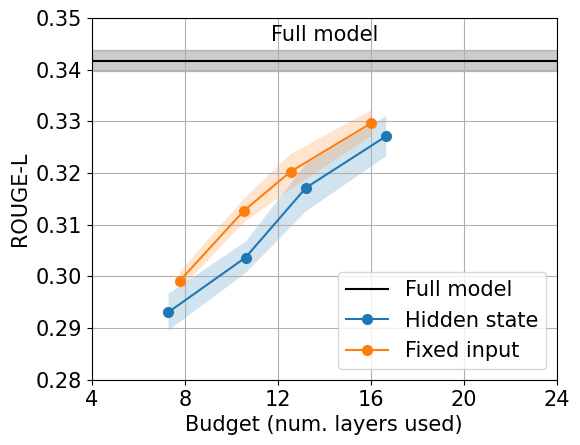

In [53]:
#plot RougeL against avg layer use
plt.figure(figsize=(6, 4.7))
plt.rcParams.update({'font.size': 15})
#plot with max-min error bars for each alpha
avg_rouge_full_prop = np.mean(full_prop_rougeL)
full_prop_std = np.std(full_prop_rougeL)
plt.axhline(y=avg_rouge_full_prop, color=(0,0,0), linestyle='-',label='Full model')
plt.fill_between([0,24], avg_rouge_full_prop-full_prop_std, avg_rouge_full_prop+full_prop_std, color=(0,0,0), alpha=0.2)

# avg_rouge_eval_full_prop = np.mean(eval_full_prop_rougeL)
# eval_full_prop_std = np.std(eval_full_prop_rougeL)
# plt.axhline(y=avg_rouge_eval_full_prop, color=(0,0,0), linestyle='--',label='Full model eval')
# plt.fill_between([0,24], avg_rouge_eval_full_prop-eval_full_prop_std, avg_rouge_eval_full_prop+eval_full_prop_std, color=(0,0,0), alpha=0.2)

avg_rouge_HS = [np.mean(HS_rougeL[i]) for i in range(len(alphas))]
std_rouge_HS = [np.std(HS_rougeL[i]) for i in range(len(alphas))]
perc_skip_HS = [np.mean(HS_perc_skip[i]) for i in range(len(alphas))]
perc_layer_use_HS = [(1 - perc_skip_HS[i])*24.0 for i in range(len(alphas))]
plt.plot(perc_layer_use_HS, avg_rouge_HS, label="Hidden state", marker='o',markersize=7)
plt.fill_between(perc_layer_use_HS, np.array(avg_rouge_HS)-np.array(std_rouge_HS), np.array(avg_rouge_HS)+np.array(std_rouge_HS), alpha=0.2)

avg_rouge_fixed = [np.mean(fixed_rougeL[i]) for i in range(len(alphas))]
std_rouge_fixed = [np.std(fixed_rougeL[i]) for i in range(len(alphas))]
perc_skip_fixed = [np.mean(fixed_perc_skip[i]) for i in range(len(alphas))]
perc_layer_use_fixed = [(1 - perc_skip_fixed[i])*24.0 for i in range(len(alphas))]
plt.plot(perc_layer_use_fixed, avg_rouge_fixed, label="Fixed input", marker='o',markersize=7)
plt.fill_between(perc_layer_use_fixed, np.array(avg_rouge_fixed)-np.array(std_rouge_fixed), np.array(avg_rouge_fixed)+np.array(std_rouge_fixed), alpha=0.2)


# avg_rouge_eval_HS = [np.mean(eval_HS_rougeL[i]) for i in range(len(alphas))]
# std_rouge_eval_HS = [np.std(eval_HS_rougeL[i]) for i in range(len(alphas))]
# perc_skip_eval_HS = [np.mean(eval_HS_perc_skip[i]) for i in range(len(alphas))]
# perc_layer_use_eval_HS = [(1 - perc_skip_eval_HS[i])*24.0 for i in range(len(alphas))]
# plt.plot(perc_layer_use_eval_HS, avg_rouge_eval_HS, label="Hidden state eval", marker='o',markersize=7)
# plt.fill_between(perc_layer_use_eval_HS, np.array(avg_rouge_eval_HS)-np.array(std_rouge_eval_HS), np.array(avg_rouge_eval_HS)+np.array(std_rouge_eval_HS), alpha=0.2)

# avg_rouge_ULS = [np.mean(ULS_rougeL[i]) for i in range(len(FILENAMES["ULS"]))]
# std_rouge_ULS = [np.std(ULS_rougeL[i]) for i in range(len(FILENAMES["ULS"]))]
# perc_skip_ULS = [np.mean(ULS_perc_skip[i]) for i in range(len(FILENAMES["ULS"]))]
# perc_layer_use_ULS = [(1 - perc_skip_ULS[i])*24.0 for i in range(len(FILENAMES["ULS"]))]
# plt.plot(perc_layer_use_ULS, avg_rouge_ULS, label="ULS", marker='o',markersize=7)
# plt.fill_between(perc_layer_use_ULS, np.array(avg_rouge_ULS)-np.array(std_rouge_ULS), np.array(avg_rouge_ULS)+np.array(std_rouge_ULS), alpha=0.2)

#plt.plot(HS_layer_use, HS_rouge, label="Hidden state eval", marker='o',markersize=7)
#plt.plot(fixed_layer_use, fixed_rouge, label="Fixed input eval", marker='o',markersize=7)
# # plt.plot(ULS_layer_use, ULS_rouge, label="ULS eval", marker='o',markersize=7)

plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.ylim(0.28,0.35)
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()
#add text "full model"
plt.text(14, avg_rouge_full_prop + 0.005, "Full model", fontsize=15, ha='center', va='center')
#save as pdf
plt.savefig(r"data\eval_results\alpaca\layer_use_rouge.pdf", bbox_inches='tight')

In [9]:
#load JSON results

FILENAMES = {
    "hidden_state" : r"data\eval_results\alpaca\hidden_state_res.json",
    "fixed": r"data\eval_results\alpaca\fixed_res.json",
    "ULS": r"data\eval_results\alpaca\ULS_res.json",
}
alphas = [2,4,6,10]
ULS_layers = [24,12,8,6,4]
data_dict = {}
for key in FILENAMES:
    with open(FILENAMES[key], 'r') as f:
        data_dict[key] = json.load(f)

print(data_dict["hidden_state"].keys())
print(data_dict["hidden_state"]["HS_2"].keys())

dict_keys(['HS_2', 'HS_4', 'HS_6', 'HS_10'])
dict_keys(['loss', 'rougeL', 'perc_skip'])


In [10]:
HS_rouge = [data_dict["hidden_state"][f"HS_{i}"]["rougeL"] for i in alphas]
HS_loss = [data_dict["hidden_state"][f"HS_{i}"]["loss"] for i in alphas]
HS_perc_skip = [data_dict["hidden_state"][f"HS_{i}"]["perc_skip"] for i in alphas]
HS_layer_use = [(1-s)*24 for s in HS_perc_skip]

fixed_rouge = [data_dict["fixed"][f"fixed_{i}"]["rougeL"] for i in alphas]
fixed_loss = [data_dict["fixed"][f"fixed_{i}"]["loss"] for i in alphas]
fixed_perc_skip = [data_dict["fixed"][f"fixed_{i}"]["perc_skip"] for i in alphas]
fixed_layer_use = [(1-s)*24 for s in fixed_perc_skip]

ULS_rouge = [data_dict["ULS"][f"ULS_{i}"]["rougeL"] for i in ULS_layers]
ULS_loss = [data_dict["ULS"][f"ULS_{i}"]["loss"] for i in ULS_layers]
ULS_perc_skip = [data_dict["ULS"][f"ULS_{i}"]["perc_skip"] for i in ULS_layers]
ULS_layer_use = [(1-s)*24 for s in ULS_perc_skip]

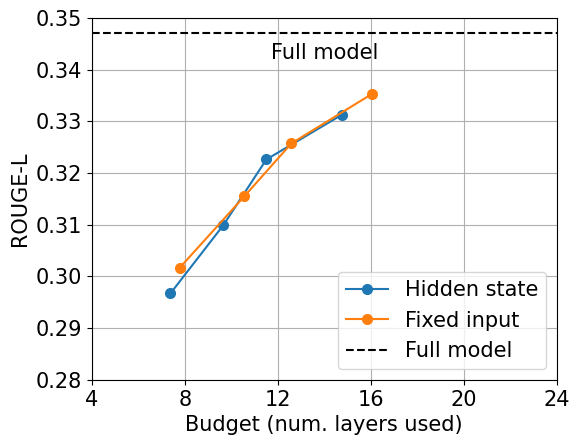

In [22]:
#plot RougeL against avg layer use
plt.figure(figsize=(6, 4.7))
plt.rcParams.update({'font.size': 15})
plt.plot(HS_layer_use, HS_rouge, label="Hidden state", marker='o',markersize=7)
plt.plot(fixed_layer_use, fixed_rouge, label="Fixed input", marker='o',markersize=7)
plt.axhline(y=data_dict["ULS"]["ULS_24"]["rougeL"], color=(0,0,0), linestyle='--',label='Full model')
plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.ylim(0.28,0.35)
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()
#add text "full model"
plt.text(14, data_dict["ULS"]["ULS_24"]["rougeL"]-0.005, 'Full model', ha='center')
#save as pdf
plt.savefig(r"data\eval_results\alpaca\layer_use_rouge.pdf", bbox_inches='tight')


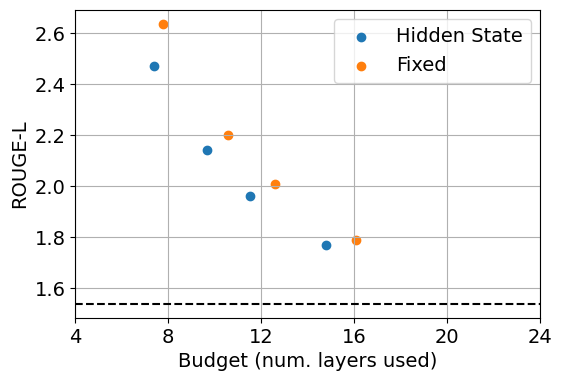

In [35]:
#plot Loss against avg layer use
plt.figure(figsize=(6, 4))
plt.rcParams.update({'font.size': 14})
plt.scatter(HS_layer_use, HS_loss, label="Hidden State")
plt.scatter(fixed_layer_use, fixed_loss, label="Fixed")
plt.axhline(y=data_dict["ULS"]["ULS_24"]["loss"], color=(0,0,0), linestyle='--')
plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()